##    -----------------------------EDA----------------------------------------

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Importer les données, vérifier types, dimensions et aperçu général.

In [51]:
df = pd.read_csv("../data/CardProfiler.csv")

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CUST_ID                 8950 non-null   str    
 1   BALANCE                 8950 non-null   float64
 2   PURCHASES               8950 non-null   float64
 3   ONEOFF_PURCHASES        8950 non-null   float64
 4   INSTALLMENTS_PURCHASES  8950 non-null   float64
 5   CASH_ADVANCE            8950 non-null   float64
 6   CREDIT_LIMIT            8949 non-null   float64
 7   PAYMENTS                8950 non-null   float64
dtypes: float64(7), str(1)
memory usage: 559.5 KB


In [53]:
df.shape

(8950, 8)

In [54]:
df.describe()

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000
mean,1564.474828,1003.204834,592.437371,411.067645,978.871112,4494.449450,1733.143852
std,2081.531879,2136.634782,1659.887917,904.338115,2097.163877,3638.815725,2895.063757
min,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000
25%,128.281915,39.635000,0.000000,0.000000,0.000000,1600.000000,383.276166
50%,873.385231,361.280000,38.000000,89.000000,0.000000,3000.000000,856.901546
75%,2054.140036,1110.130000,577.405000,468.637500,1113.821139,6500.000000,1901.134317
max,19043.138560,49039.570000,40761.250000,22500.000000,47137.211760,30000.000000,50721.483360


### Identifier valeurs manquantes et doublons.

In [55]:
df.isna().sum()

CUST_ID                   0
BALANCE                   0
PURCHASES                 0
ONEOFF_PURCHASES          0
INSTALLMENTS_PURCHASES    0
CASH_ADVANCE              0
CREDIT_LIMIT              1
PAYMENTS                  0
dtype: int64

### il y a une seule valeur manquant

In [56]:
df.duplicated().sum()

np.int64(0)

### Analyser la distribution des variables numériques : histogrammes + skewness affiché, pour repérer les variables asymétriques.

In [57]:
import matplotlib.pyplot as plt

In [58]:
import seaborn as sns

In [59]:
columns = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']

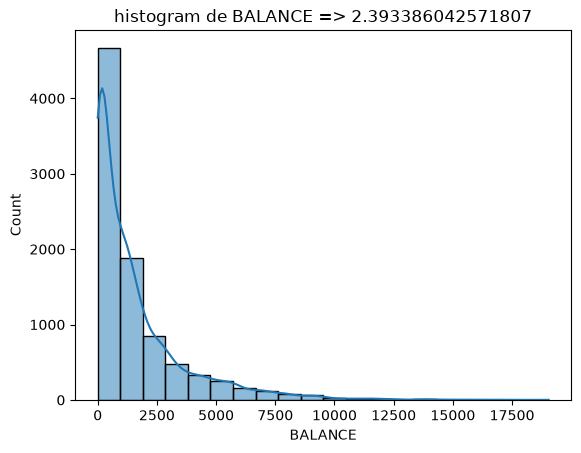

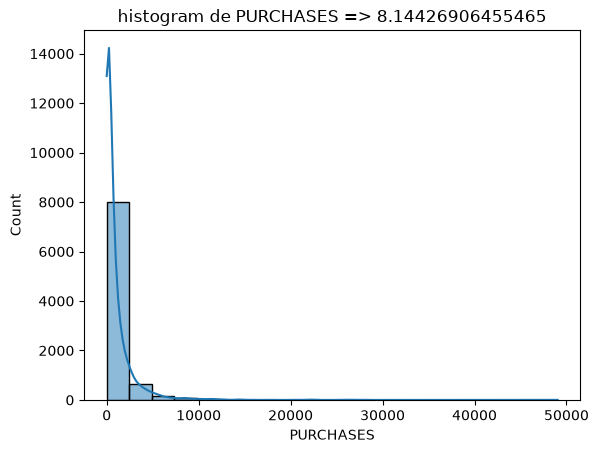

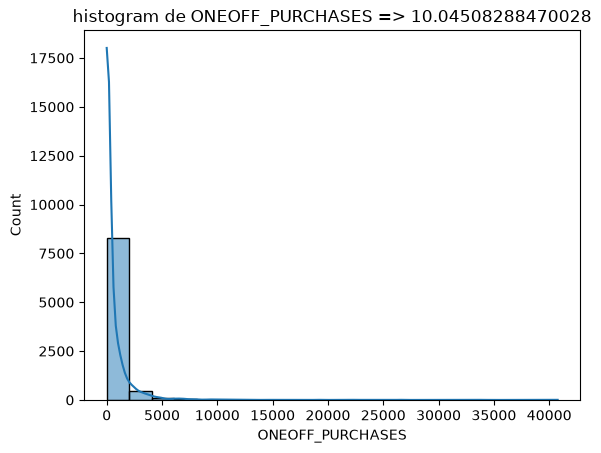

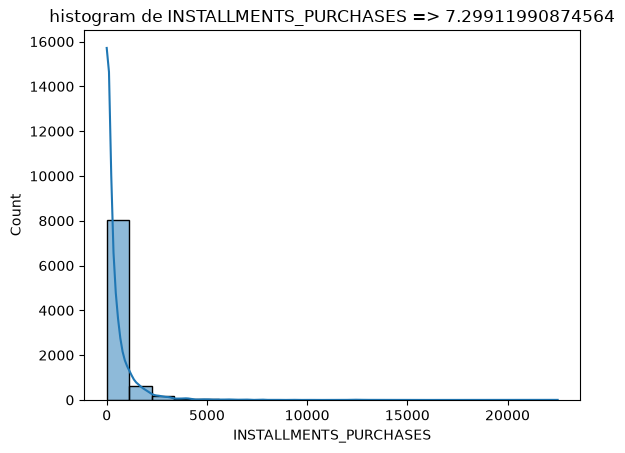

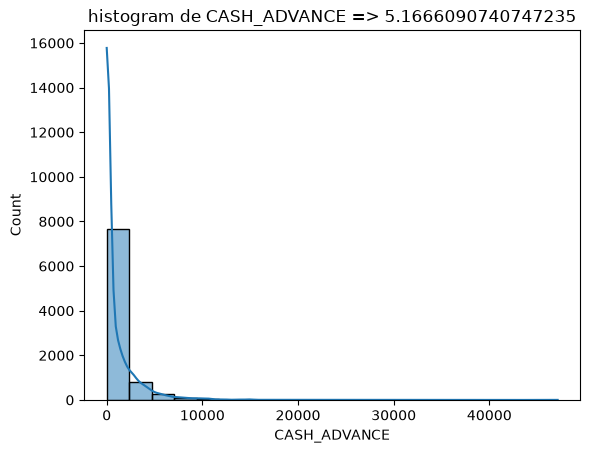

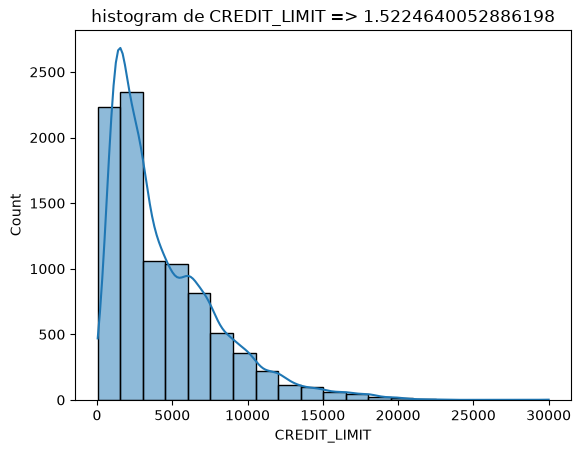

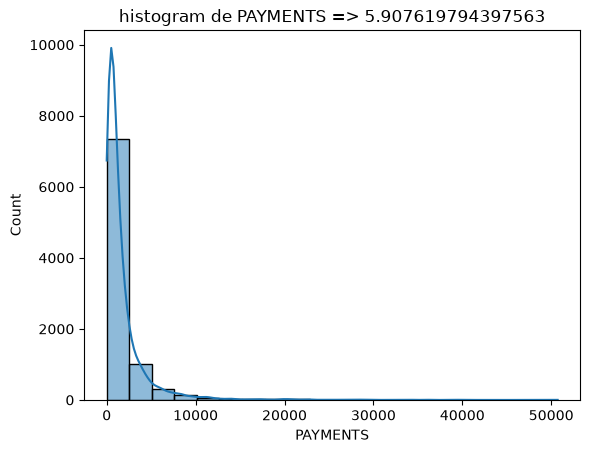

In [60]:
for col in columns:
    sns.histplot(df[col],bins=20,edgecolor='black',kde=True)
    plt.title(f'histogram de {col} => {df[col].skew()}')
    plt.show()

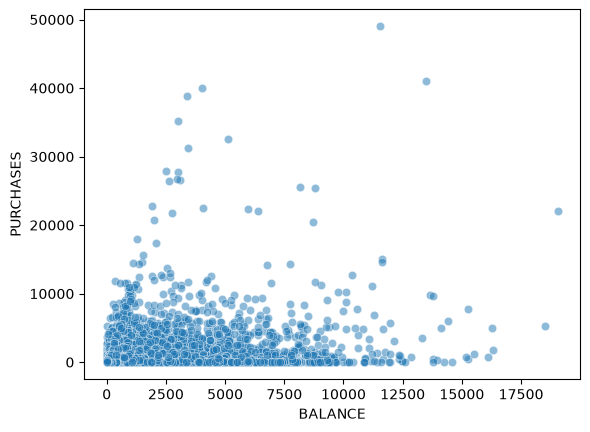

In [61]:
## SCATTER 

sns.scatterplot(data=df , x='BALANCE' , y='PURCHASES',alpha=0.5)
plt.show()

### Étudier les corrélations entre variables (heatmap de la matrice de corrélation).

In [62]:
corr = df.corr(numeric_only=True)

<Axes: >

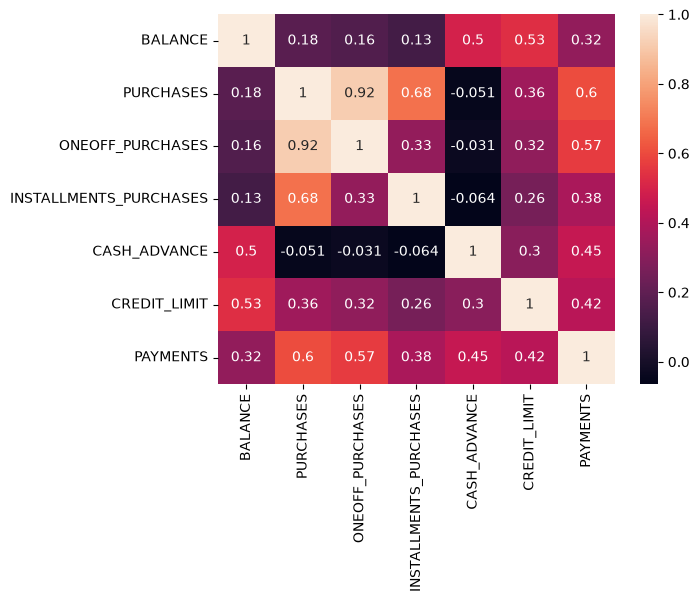

In [63]:
sns.heatmap(corr,annot=True)

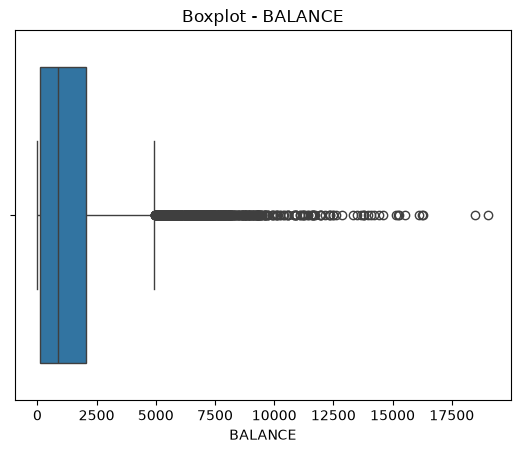

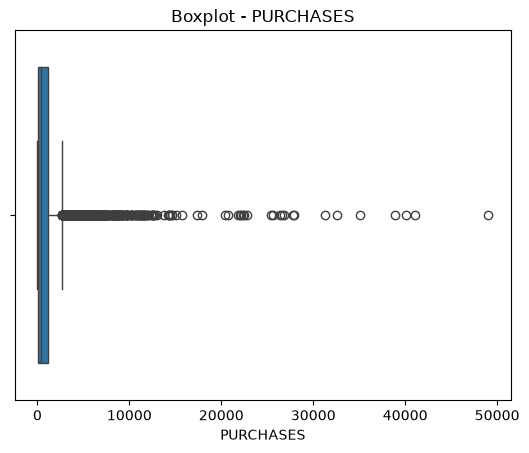

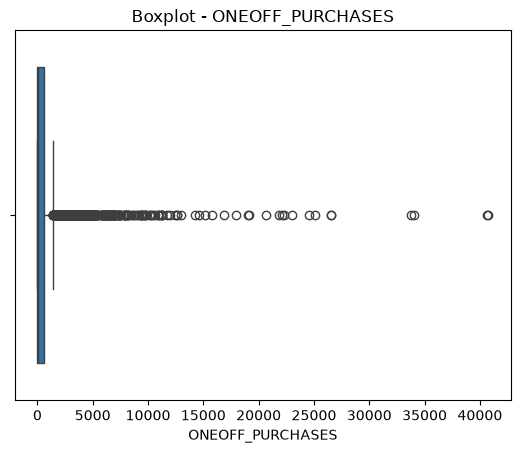

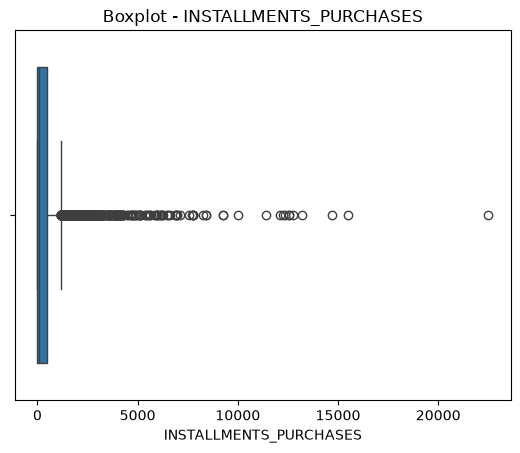

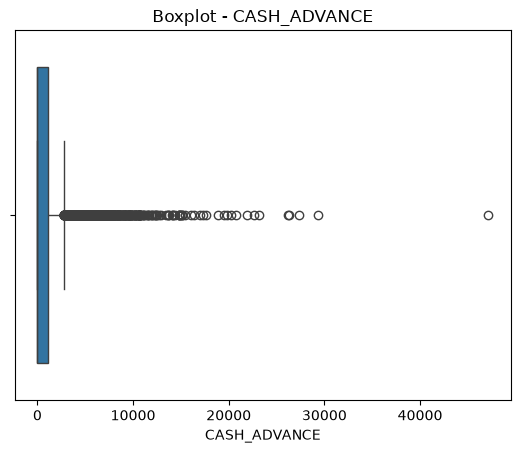

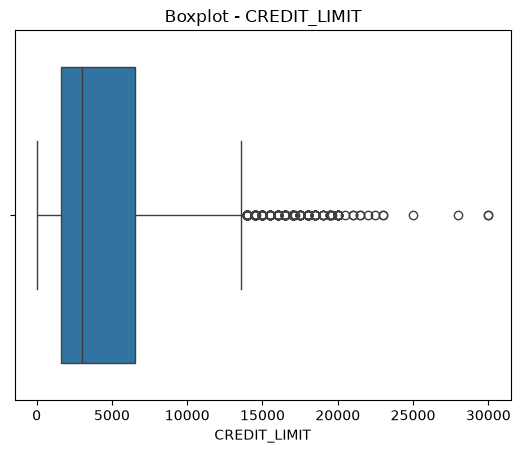

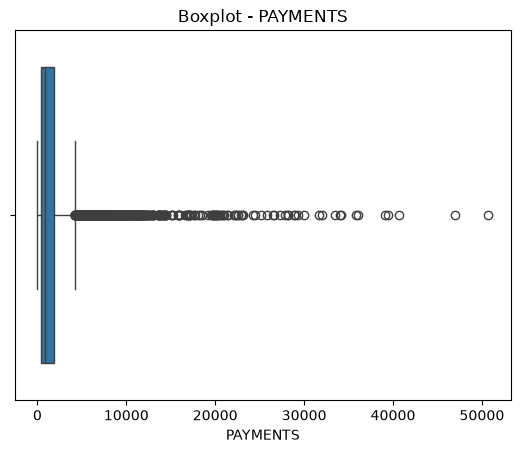

In [64]:
for col in columns:
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.show()

In [65]:
# IQR = Q3 - Q1

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lowr = Q1 - (1.5*IQR)
    upper = Q3 + (1.5*IQR)
    nb_outlire = df[(df[col] < lowr) | (df[col] > upper)]
    print(f"{col} : {len(nb_outlire)}")

BALANCE : 695
PURCHASES : 808
ONEOFF_PURCHASES : 1013
INSTALLMENTS_PURCHASES : 867
CASH_ADVANCE : 1030
CREDIT_LIMIT : 248
PAYMENTS : 808


In [66]:
# Z-scor = (x - mean) / std
    

## ------------------------------------preprocessing---------------------------------------------------

## Nettoyage minimal

In [67]:
df_clean = df.drop('CUST_ID' ,axis=1)
df_clean

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
0,40.900749,95.40,0.00,95.40,0.000000,1000.0,201.802084
1,3202.467416,0.00,0.00,0.00,6442.945483,7000.0,4103.032597
2,2495.148862,773.17,773.17,0.00,0.000000,7500.0,622.066742
3,1666.670542,1499.00,1499.00,0.00,205.788017,7500.0,0.000000
4,817.714335,16.00,16.00,0.00,0.000000,1200.0,678.334763
...,...,...,...,...,...,...,...
8945,28.493517,291.12,0.00,291.12,0.000000,1000.0,325.594462
8946,19.183215,300.00,0.00,300.00,0.000000,1000.0,275.861322
8947,23.398673,144.40,0.00,144.40,0.000000,1000.0,81.270775
8948,13.457564,0.00,0.00,0.00,36.558778,500.0,52.549959


### remplace les valeur manquant

In [68]:
df_clean['CREDIT_LIMIT'] = df_clean['CREDIT_LIMIT'].fillna(df_clean['CREDIT_LIMIT'].mean())

### Transformation logarithmique

#### toutes les variables sont positives , donc nous pouvons appliquer une transformation

In [69]:
import numpy as np

In [70]:
df_log = np.log1p(df_clean)

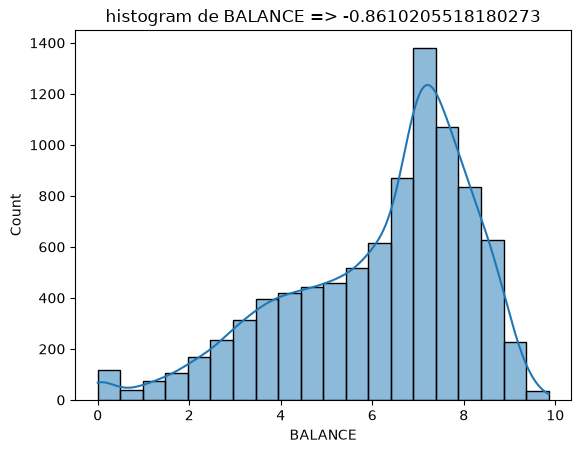

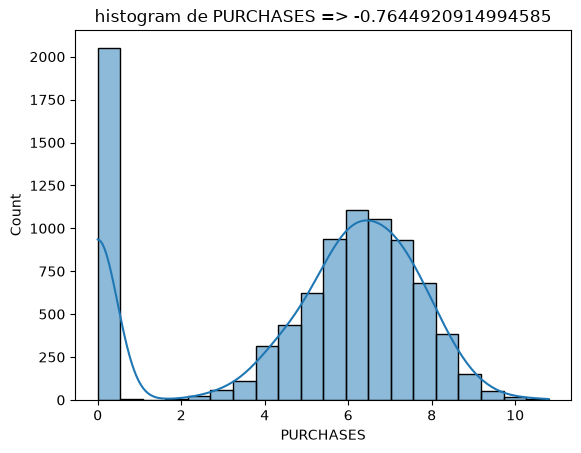

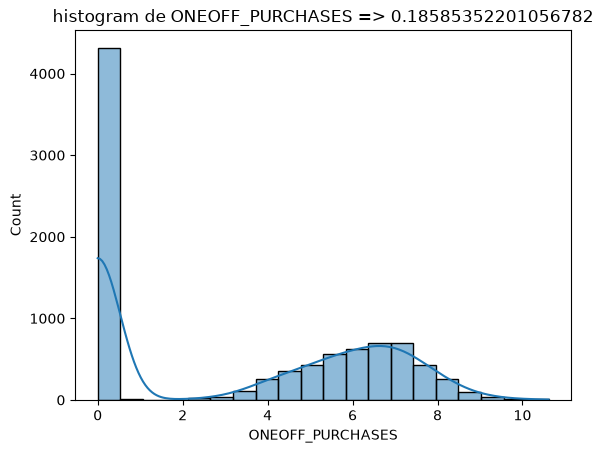

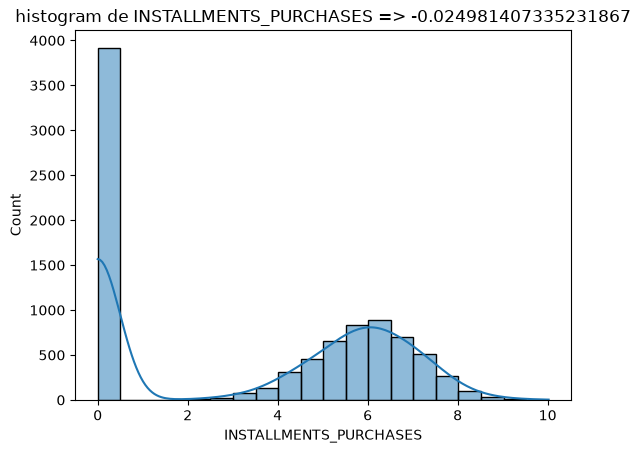

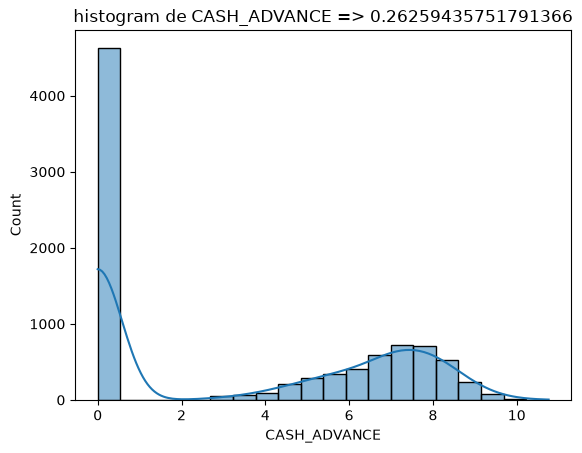

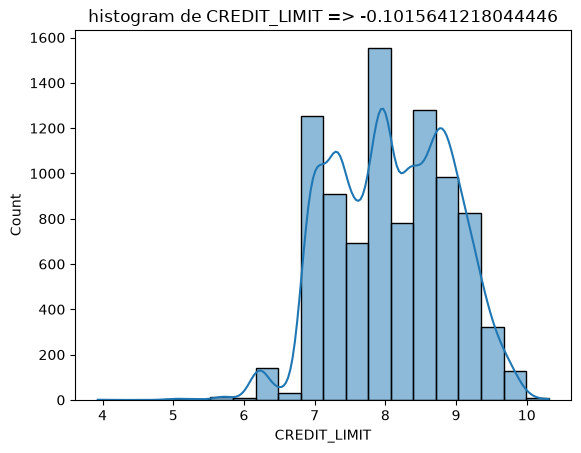

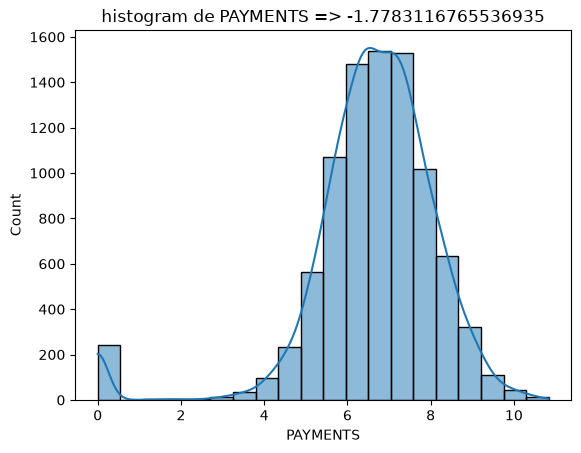

In [71]:
for col in df_log.columns:
    sns.histplot(df_log[col],bins=20,edgecolor='black',kde=True)
    plt.title(f'histogram de {col} => {df_log[col].skew()}')
    plt.show()

## Préparation clustering

In [72]:
from sklearn.preprocessing import StandardScaler

In [73]:
scaler = StandardScaler()
df_prepare_clustering = scaler.fit_transform(df_log)
display(df_prepare_clustering)

array([[-1.20521818, -0.11353236, -0.98708958, ..., -0.93073294,
        -1.44720655, -0.82448405],
       [ 0.94891762, -1.67985462, -0.98708958, ...,  1.52878819,
         0.92599804,  1.06503312],
       [ 0.82499258,  0.60072652,  1.06202168, ..., -0.93073294,
         1.01016621, -0.11929988],
       ...,
       [-1.4738341 ,  0.02737383, -0.98708958, ..., -0.93073294,
        -1.44720655, -1.39131795],
       [-1.73377525, -1.67985462, -0.98708958, ...,  0.08603831,
        -2.2917131 , -1.66109743],
       [-0.11830096,  0.71936468,  1.16861854, ...,  0.42995349,
        -1.22495498, -1.54747543]], shape=(8950, 7))

In [74]:
from sklearn.decomposition import PCA

In [75]:
pca = PCA()

In [92]:
df_pca = pca.fit_transform(df_prepare_clustering)
display(pca.fit_transform(df_pca))

array([[-0.45869705, -2.34263404, -0.57507781, ...,  0.11894462,
        -0.09314018,  0.05076559],
       [-2.09847013,  2.19018343, -0.56094452, ...,  0.55096093,
         0.01152117, -0.09546935],
       [ 0.8301959 ,  0.71385719,  1.56961544, ...,  0.15372849,
        -1.07201332,  0.39045099],
       ...,
       [-0.42706375, -2.79264065, -0.43677403, ..., -0.27042806,
         0.07111661,  0.08145691],
       [-2.79493941, -2.6354695 ,  0.48395528, ...,  0.24444394,
         0.5341658 , -0.42701902],
       [-0.28828109, -0.77152215,  2.01024071, ..., -0.88047287,
         0.4928473 ,  0.44430396]], shape=(8950, 7))

In [77]:
print(pca.explained_variance_ratio_)

[0.35365879 0.29254805 0.11395959 0.10009634 0.07623782 0.04969959
 0.01379983]


In [78]:
cumulative_varaince = np.cumsum(pca.explained_variance_ratio_)

In [81]:
n_component = np.argmax(cumulative_varaince >= 0.80) + 1

In [82]:
print(n_component)

4


#### donc nous avons la possibilité de représenter les données avec 4 component au lieu de 7

## Courbe de variance expliquée cumulée de la PCA

In [85]:
import matplotlib.pyplot as plt

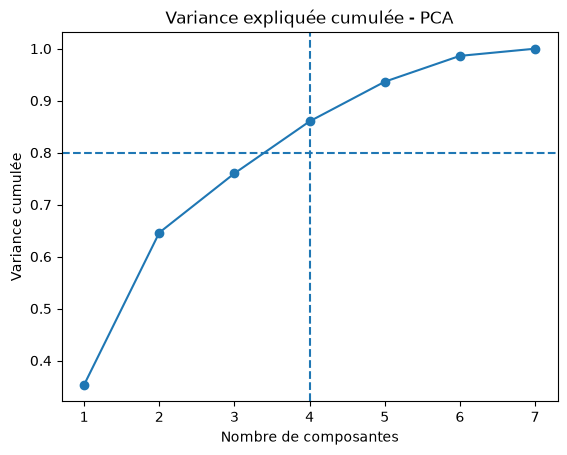

In [86]:
plt.plot(
    range(1,len(cumulative_varaince)+1),
    cumulative_varaince,
    marker="o"
)

plt.axhline(
    y=0.80,
    linestyle="--"
)
plt.axvline(
    x=n_component,
    linestyle="--"
)

plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulée")
plt.title("Variance expliquée cumulée - PCA")

plt.show()

## Feature Story 3 : Entraînement des modèles de clustering (K-means et DBSCAN)


**. Recherche en grille K-means**

In [91]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [102]:
results = []

for n_component in range(2,6):
    compoent = df_pca[:,:n_component]

    for k in range(2,8):
        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        label = model.fit_predict(component)
        results.append({
           "n_component" : n_component,
           "k" : k,
           "inertia" : model.inertia_,
           "silhouette" : silhouette_score(
               component,
               label
           )
           })  
result_df = pd.DataFrame(results)

## Synthétiser en heatmap(composantes × k, valeur = silhouette)

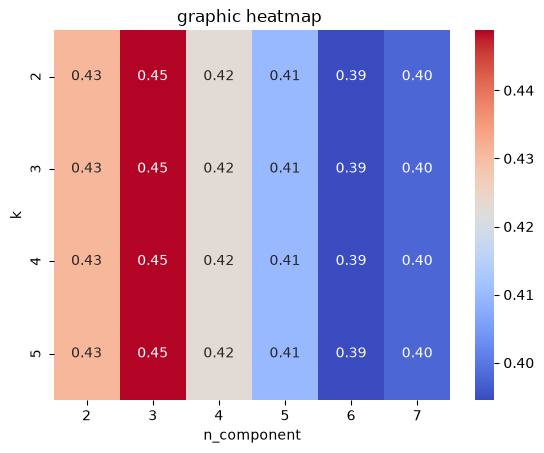

In [105]:
heatmap_data = result_df.pivot(
    index = "n_component",
    columns = "k",
    values = "silhouette"
)

sns.heatmap(
    heatmap_data,
    annot= True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("graphic heatmap ")
plt.xlabel("n_component")
plt.ylabel("k")
plt.show()

## courbe elbow

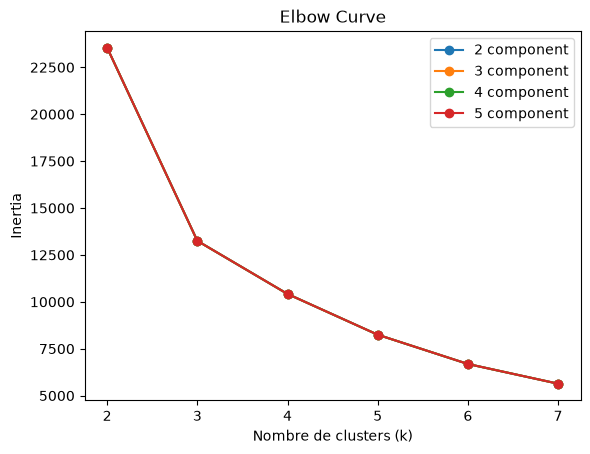

In [106]:
for n_component in range(2,6):
    subset = result_df[result_df['n_component'] == n_component]
    plt.plot(
        subset['k'],
        subset['inertia'],
        marker="o",
        label=f"{n_component} component"
    )

plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Curve")

plt.legend()
plt.show()

## Silhouette Curve

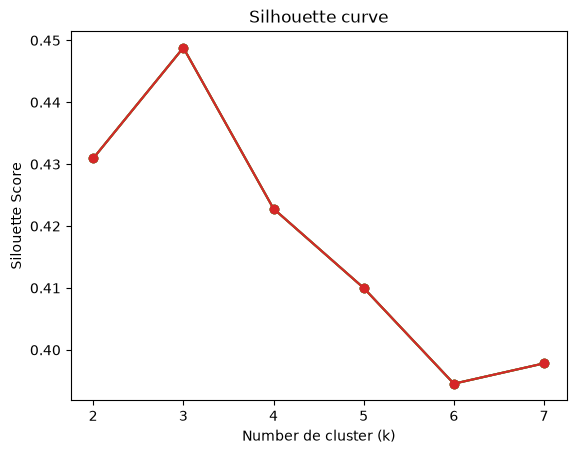

In [108]:
for n_component in range(2,6):
    subset = result_df[result_df['n_component'] == n_component]
    plt.plot(
        subset['k'],
        subset['silhouette'],
        marker="o",
        label=f"{n_component} components"
    )
plt.title("Silhouette curve")
plt.xlabel('Number de cluster (k)')
plt.ylabel("Silouette Score")
plt.show()

In [110]:
mieur_choix = result_df.loc[result_df['silhouette'].idxmax()]
print(mieur_choix)

n_component        2.000000
k                  3.000000
inertia        13249.458594
silhouette         0.448812
Name: 1, dtype: float64


### Don cle meieur choix et k=3 et n_component=2

In [113]:
component_final = df_pca[:,:3]

In [115]:
kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

label_final = kmeans_final.fit_predict(component_final)

###  rattacher le résultat à df_clean sous forme de colonne cluster_kmeans.

In [121]:
df_clean['cluster_kmeans'] = label_final

## . Recherche en grille DBSCAN